<a href="https://colab.research.google.com/github/ashwika232/api_silent_failures/blob/main/silent_failures_in_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install and Import

In [ ]:
!pip install tensorflow pandas scikit-learn numpy
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import tensorflow as tf
import json

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Load Separate Train & Test Logs

In [ ]:
train_df = pd.read_csv("training_data_2000.csv")   # Only NORMAL workflows
test_df  = pd.read_csv("testing_data_2000.csv")     # Normal + Anomalies

train_df = train_df.sort_values(by=["workflow_id", "start"]).reset_index(drop=True)
test_df  = test_df.sort_values(by=["workflow_id", "start"]).reset_index(drop=True)

# ── Shuffle test workflows (keep 7-row groups intact) ──────────────────
test_wf_ids = test_df["workflow_id"].unique().tolist()
random.seed(42)
random.shuffle(test_wf_ids)

test_df = pd.concat(
    [test_df[test_df["workflow_id"] == wf_id] for wf_id in test_wf_ids],
    ignore_index=True
)

print("Train workflows:", train_df["workflow_id"].nunique())
print("Test workflows :", test_df["workflow_id"].nunique())
print("Rows per train workflow:", train_df.groupby("workflow_id").size().unique())
print("Rows per test workflow :", test_df.groupby("workflow_id").size().unique())

Train workflows: 2000
Test workflows : 2000
Rows per train workflow: [7]
Rows per test workflow : [7]


Feature Engineering Function (Reusable)

In [ ]:
def build_feature_dataframe(df):
    feature_rows = []
    workflow_ids = []

    grouped = df.groupby("workflow_id", sort=False)

    for wf_id, group in grouped:
        group = group.sort_values("start")

        latencies = group["latency"].tolist()
        responses = group["response_size"].tolist()

        # gaps = [
        #     group.iloc[i+1]["start"] - group.iloc[i]["end"]
        #     for i in range(len(group)-1)
        # ]
        gaps = [
              max(0, group.iloc[i+1]["start"] - group.iloc[i]["end"])
              for i in range(len(group) - 1)
        ]

        feature_vector = latencies + responses + gaps

        feature_rows.append(feature_vector)
        workflow_ids.append(wf_id)

    return pd.DataFrame(feature_rows), workflow_ids

Create Feature Data

In [ ]:
train_features, train_workflow_ids = build_feature_dataframe(train_df)
test_features,  test_workflow_ids  = build_feature_dataframe(test_df)

print("Train feature shape:", train_features.shape)
print("Test feature shape :", test_features.shape)

Train feature shape: (2000, 20)
Test feature shape : (2000, 20)


Generate Feature Names (Based on Train Data)

In [ ]:
api_list = train_df["api_name"].unique().tolist()

lat_features  = [f"{api}_latency"       for api in api_list]
resp_features = [f"{api}_response_size" for api in api_list]
gap_features  = [f"Gap_{i+1}"           for i in range(len(api_list)-1)]

feature_names = lat_features + resp_features + gap_features

train_features.columns = feature_names
test_features.columns  = feature_names

print("Features:", feature_names)

Features: ['UserAuthAPI_latency', 'ProductCatalogAPI_latency', 'InventoryCheckAPI_latency', 'FraudDetectionAPI_latency', 'PaymentGatewayAPI_latency', 'ShippingServiceAPI_latency', 'NotificationAPI_latency', 'UserAuthAPI_response_size', 'ProductCatalogAPI_response_size', 'InventoryCheckAPI_response_size', 'FraudDetectionAPI_response_size', 'PaymentGatewayAPI_response_size', 'ShippingServiceAPI_response_size', 'NotificationAPI_response_size', 'Gap_1', 'Gap_2', 'Gap_3', 'Gap_4', 'Gap_5', 'Gap_6']


Normalize (Fit Only On Training Data)

In [ ]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(train_features)
X_test_scaled  = scaler.transform(test_features)

Train Autoencoder (Only On Normal Training Data)

In [ ]:
input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)
encoded = Dense(8,  activation='relu')(encoded)

decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=200,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5774
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4554
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3374
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3283
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3270
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3254
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3234
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3203
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3166
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3137
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3110
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3083
Epoch 13/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3059
Epoch 14/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3041
Epoch 15/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3023

Compute Threshold (ONLY From Training Data)

In [ ]:
train_reconstructions = autoencoder.predict(X_train_scaled, verbose=0)
train_mse = np.mean(np.square(X_train_scaled - train_reconstructions), axis=1)

threshold = np.mean(train_mse) + 3 * np.std(train_mse)

print("Workflow Anomaly Threshold:", threshold)

# Feature-Level Thresholds
train_feature_errors = np.square(X_train_scaled - train_reconstructions)

feature_means = np.mean(train_feature_errors, axis=0)
feature_stds  = np.std(train_feature_errors,  axis=0)

feature_thresholds = feature_means + 3 * feature_stds

print("Feature Thresholds Computed")

Workflow Anomaly Threshold: 0.43103718833316895
Feature Thresholds Computed


Test On Separate Test Data

In [ ]:
test_reconstructions = autoencoder.predict(X_test_scaled, verbose=0)
test_mse = np.mean(np.square(X_test_scaled - test_reconstructions), axis=1)

Detailed Explanation Generator

In [ ]:
def generate_detailed_explanation(index):

    original_scaled    = X_test_scaled[index]
    reconstructed_scaled = test_reconstructions[index]

    original     = scaler.inverse_transform([original_scaled])[0]
    reconstructed = scaler.inverse_transform([reconstructed_scaled])[0]

    error_vector = np.square(original_scaled - reconstructed_scaled)

    deviations = []

    for idx, error in enumerate(error_vector):
        if error > feature_thresholds[idx]:
            feature_name = feature_names[idx]

            if feature_name.endswith("_latency"):
                api          = feature_name.replace("_latency", "")
                feature_type = "latency"
            elif feature_name.endswith("_response_size"):
                api          = feature_name.replace("_response_size", "")
                feature_type = "response_size"
            else:
                api          = feature_name
                feature_type = "workflow_metric"

            deviations.append({
                "api":            api,
                "feature":        feature_type,
                "observed":       round(original[idx], 2),
                "expected_normal": round(reconstructed[idx], 2),
                "deviation":      round(abs(original[idx] - reconstructed[idx]), 2)
            })

    return {
        "workflow_id":  test_workflow_ids[index],
        "status":       "ALERT" if test_mse[index] > threshold else "NORMAL",
        "anomaly_score": round(float(test_mse[index]), 4),
        "deviations":   deviations
    }

Generate Final Results

In [ ]:
results = []

for i in range(len(test_features)):
    if test_mse[i] > threshold:
        results.append(generate_detailed_explanation(i))

print(json.dumps(results, indent=2))

[
  {
    "workflow_id": 3469,
    "status": "ALERT",
    "anomaly_score": 8.7906,
    "deviations": [
      {
        "api": "FraudDetectionAPI",
        "feature": "latency",
        "observed": 304.0,
        "expected_normal": 79.0,
        "deviation": 225.0
      },
      {
        "api": "NotificationAPI",
        "feature": "latency",
        "observed": 55.0,
        "expected_normal": 119.99,
        "deviation": 64.99
      },
      {
        "api": "ShippingServiceAPI",
        "feature": "response_size",
        "observed": 3958.0,
        "expected_normal": 1270.0,
        "deviation": 2688.0
      },
      {
        "api": "Gap_4",
        "feature": "workflow_metric",
        "observed": 14.0,
        "expected_normal": 2.0,
        "deviation": 12.0
      },
      {
        "api": "Gap_6",
        "feature": "workflow_metric",
        "observed": 23.0,
        "expected_normal": 4.0,
        "deviation": 19.0
      }
    ]
  },
  {
    "workflow_id": 3506,
    "status"

Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1 = anomaly, 0 = normal
y_pred = (test_mse > threshold).astype(int)

# Ground truth: workflow IDs 3401-4000 are anomalies
true_anomaly_ids = list(range(3401, 4001))
y_true = np.array([1 if wf in true_anomaly_ids else 0 for wf in test_workflow_ids])

accuracy  = accuracy_score(y_true,  y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true,    y_pred)
f1        = f1_score(y_true,        y_pred)
cm        = confusion_matrix(y_true, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print("Accuracy :", round(accuracy,  4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall,    4))
print("F1 Score :", round(f1,        4))
print("\nConfusion Matrix:")
print(cm)


===== MODEL PERFORMANCE =====
Accuracy : 0.994
Precision: 0.9804
Recall   : 1.0
F1 Score : 0.9901

Confusion Matrix:
[[1388   12]
 [   0  600]]


Visualisation

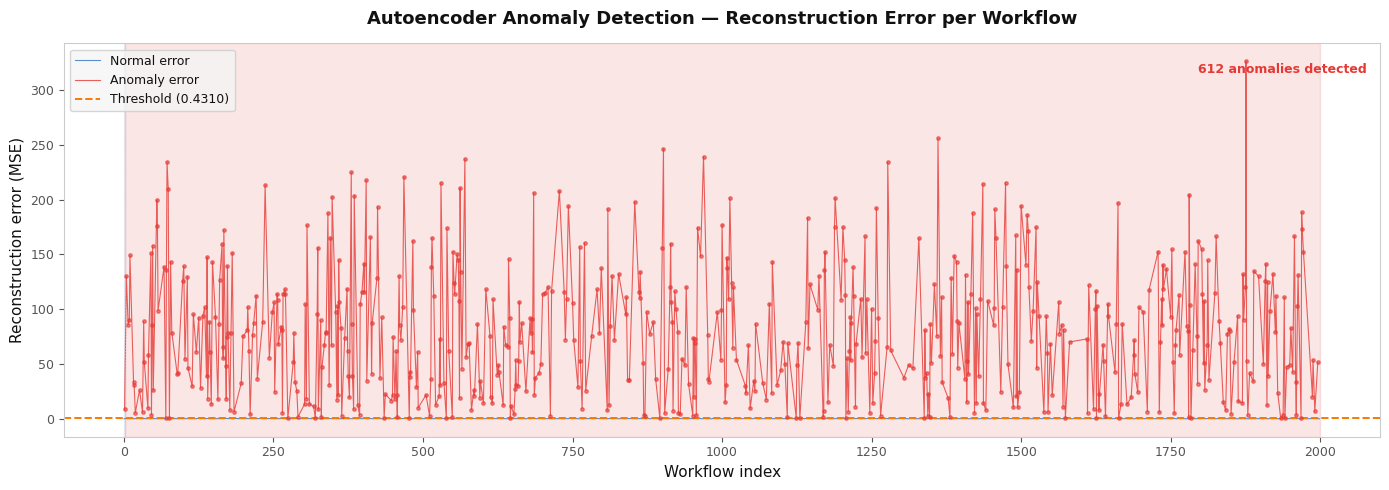

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # ── colours (light theme) ──────────────────────────────────────────────
# BG            = 'white'
# COL_NORMAL    = '#1565c0'
# COL_ANOMALY   = '#e53935'
# COL_THRESHOLD = '#f57c00'
# COL_TEXT      = '#111111'
# COL_SPINE     = '#cccccc'
# COL_TICK      = '#555555'
# LEGEND_BG     = '#f5f5f5'
# LEGEND_EDGE   = '#cccccc'

# # ── data prep ─────────────────────────────────────────────────────────
# X_test_pred          = autoencoder.predict(X_test_scaled, verbose=0)
# reconstruction_error = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

# train_pred  = autoencoder.predict(X_train_scaled, verbose=0)
# train_error = np.mean(np.square(X_train_scaled - train_pred), axis=1)
# threshold   = np.mean(train_error) + 3 * np.std(train_error)

# n          = len(reconstruction_error)
# indices    = np.arange(n)
# is_anomaly = reconstruction_error > threshold
# is_normal  = ~is_anomaly

# # ── anomaly_start: find actual index of first anomaly ID in shuffled order
# anomaly_start = next(
#     (i for i, wf in enumerate(test_workflow_ids) if wf in set(range(3401, 4001))),
#     n
# )

# # ── plot ──────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(14, 5))
# fig.patch.set_facecolor(BG)
# ax.set_facecolor(BG)

# ax.axvspan(0,             anomaly_start, alpha=0.08, color=COL_NORMAL,  label='_nolegend_')
# ax.axvspan(anomaly_start, n,             alpha=0.12, color=COL_ANOMALY, label='_nolegend_')

# ax.plot(indices[is_normal],  reconstruction_error[is_normal],
#         color=COL_NORMAL,  lw=0.8, alpha=0.7, label='Normal error')
# ax.plot(indices[is_anomaly], reconstruction_error[is_anomaly],
#         color=COL_ANOMALY, lw=0.8, alpha=0.8, label='Anomaly error')

# ax.axhline(threshold, color=COL_THRESHOLD, lw=1.4, linestyle='--',
#            label=f'Threshold ({threshold:.4f})')

# ax.scatter(indices[is_anomaly], reconstruction_error[is_anomaly],
#            color=COL_ANOMALY, s=6, zorder=5, alpha=0.6, label='_nolegend_')

# ax.axvline(anomaly_start, color=COL_SPINE, lw=0.8, linestyle=':', alpha=0.6)

# ax.set_xlabel('Workflow index',             color=COL_TEXT, fontsize=11)
# ax.set_ylabel('Reconstruction error (MSE)', color=COL_TEXT, fontsize=11)
# ax.set_title('Autoencoder Anomaly Detection — Reconstruction Error per Workflow',
#              color=COL_TEXT, fontsize=13, fontweight='bold', pad=14)

# ax.tick_params(colors=COL_TICK, labelsize=9)
# for spine in ax.spines.values():
#     spine.set_edgecolor(COL_SPINE)

# ax.legend(facecolor=LEGEND_BG, edgecolor=LEGEND_EDGE,
#           labelcolor=COL_TEXT, fontsize=9, loc='upper left')

# ax.annotate(f'{is_anomaly.sum()} anomalies detected',
#             xy=(0.99, 0.95), xycoords='axes fraction',
#             ha='right', va='top', fontsize=9,
#             color=COL_ANOMALY, fontweight='bold')

# plt.tight_layout()
# plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight',
#             facecolor=fig.get_facecolor())
# plt.show()

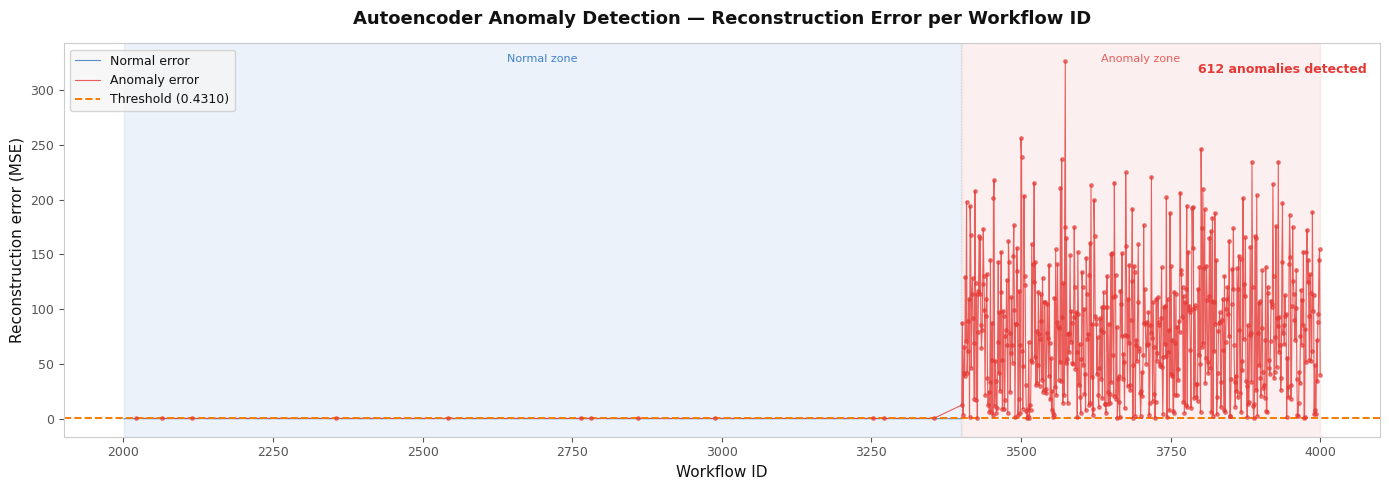

In [ ]:
BG            = 'white'
COL_NORMAL    = '#1565c0'
COL_ANOMALY   = '#e53935'
COL_THRESHOLD = '#f57c00'
COL_TEXT      = '#111111'
COL_SPINE     = '#cccccc'
COL_TICK      = '#555555'
LEGEND_BG     = '#f5f5f5'
LEGEND_EDGE   = '#cccccc'

# ── Sort everything by workflow ID ─────────────────────────────────────
sorted_indices   = np.argsort(test_workflow_ids)
sorted_wf_ids    = np.array(test_workflow_ids)[sorted_indices]
sorted_mse       = test_mse[sorted_indices]

is_anomaly = sorted_mse > threshold
is_normal  = ~is_anomaly

x_vals = sorted_wf_ids   # x-axis is now actual workflow ID

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Background shading by ID region
ax.axvspan(sorted_wf_ids[0],  3400, alpha=0.08, color=COL_NORMAL,  label='_nolegend_')
ax.axvspan(3401, sorted_wf_ids[-1], alpha=0.08, color=COL_ANOMALY, label='_nolegend_')
ax.axvline(3400, color=COL_SPINE, lw=0.8, linestyle=':', alpha=0.6)

ax.plot(x_vals[is_normal],  sorted_mse[is_normal],
        color=COL_NORMAL,  lw=0.8, alpha=0.7, label='Normal error')
ax.plot(x_vals[is_anomaly], sorted_mse[is_anomaly],
        color=COL_ANOMALY, lw=0.8, alpha=0.8, label='Anomaly error')

ax.axhline(threshold, color=COL_THRESHOLD, lw=1.4, linestyle='--',
           label=f'Threshold ({threshold:.4f})')

ax.scatter(x_vals[is_anomaly], sorted_mse[is_anomaly],
           color=COL_ANOMALY, s=6, zorder=5, alpha=0.6, label='_nolegend_')

# Zone labels
ax.text(2700, ax.get_ylim()[1] * 0.95, 'Normal zone',
        ha='center', fontsize=8, color=COL_NORMAL, alpha=0.8)
ax.text(3700, ax.get_ylim()[1] * 0.95, 'Anomaly zone',
        ha='center', fontsize=8, color=COL_ANOMALY, alpha=0.8)

ax.set_xlabel('Workflow ID',                color=COL_TEXT, fontsize=11)
ax.set_ylabel('Reconstruction error (MSE)', color=COL_TEXT, fontsize=11)
ax.set_title('Autoencoder Anomaly Detection — Reconstruction Error per Workflow ID',
             color=COL_TEXT, fontsize=13, fontweight='bold', pad=14)

ax.tick_params(colors=COL_TICK, labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(COL_SPINE)

ax.legend(facecolor=LEGEND_BG, edgecolor=LEGEND_EDGE,
          labelcolor=COL_TEXT, fontsize=9, loc='upper left')

ax.annotate(f'{is_anomaly.sum()} anomalies detected',
            xy=(0.99, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            color=COL_ANOMALY, fontweight='bold')

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

Save Results

In [ ]:
results_df = pd.DataFrame([{
    "workflow_id":  r["workflow_id"],
    "status":       r["status"],
    "anomaly_score": r["anomaly_score"]
} for r in results])

results_df.to_csv("results.csv", index=False)
print("Results saved to results.csv")

Results saved to results.csv
